In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

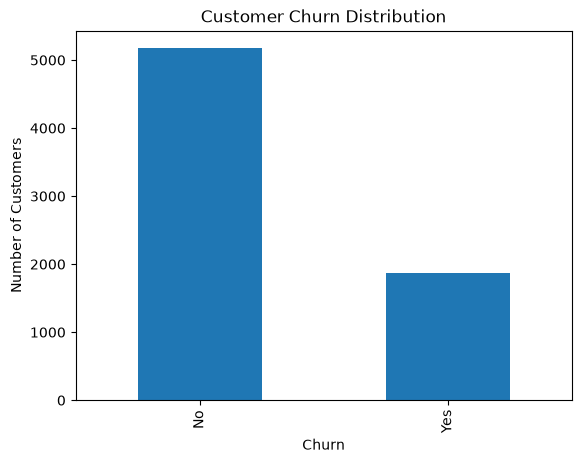

In [11]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [12]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


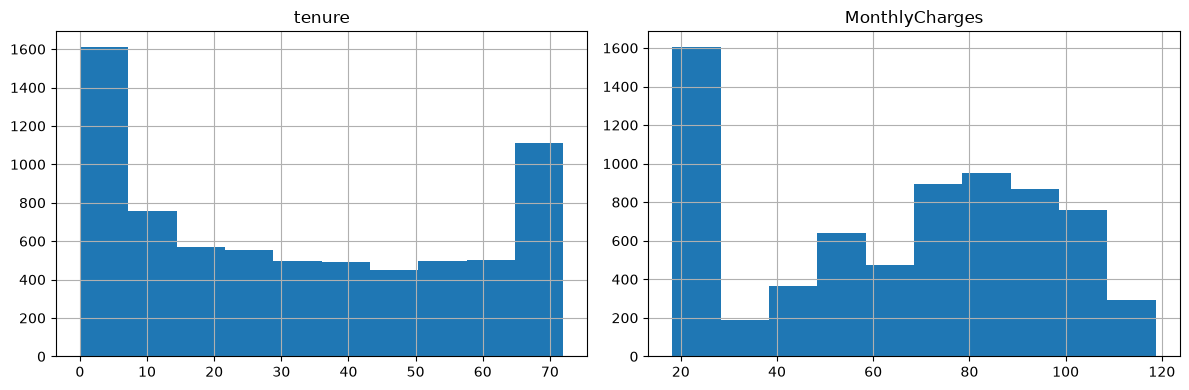

In [13]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()


In [14]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [15]:
pd.crosstab(df["Contract"], df["Churn"])


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [16]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


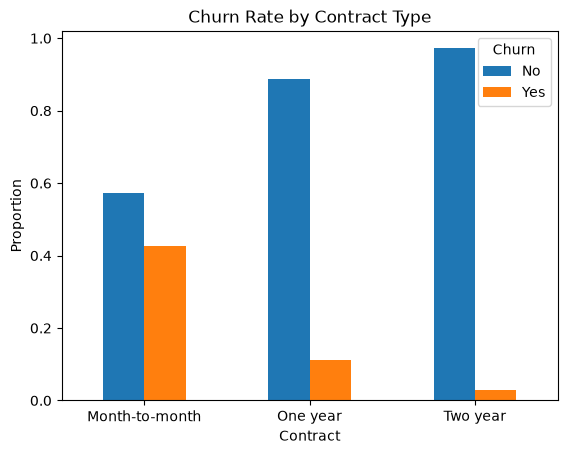

In [17]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [18]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [19]:
df[df["TotalCharges"].str.strip() == ""][["tenure", "TotalCharges", "Churn", "Contract"]]


,tenure,TotalCharges,Churn,Contract
488,0,,No,Two year
753,0,,No,Two year
936,0,,No,Two year
1082,0,,No,Two year
1340,0,,No,Two year
3331,0,,No,Two year
3826,0,,No,Two year
4380,0,,No,Two year
5218,0,,No,One year
6670,0,,No,Two year


In [20]:
(df.loc[df["TotalCharges"].str.strip() == "", "tenure"] == 0).all()


np.True_

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [22]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [23]:
df["TotalCharges"].dtype

dtype('float64')

In [24]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [25]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.duplicated().sum()


np.int64(0)

In [27]:
df["customerID"].nunique()

7043

In [28]:
len(df)

7043

In [29]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())
    


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

C:\Users\HP\AppData\Local\Temp\ipykernel_4488\789821577.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [30]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [31]:
X.shape


(7043, 20)

In [32]:
y.shape

(7043,)

In [33]:
X = X.drop("customerID", axis=1)
X.shape

(7043, 19)

In [34]:
y = y.map({"No": 0, "Yes": 1})
y.value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((5634, 19), (1409, 19), (5634,), (1409,))

In [37]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\HP\AppData\Local\Temp\ipykernel_4488\28869207.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


In [38]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Training: (4507, 19)
Validation: (1127, 19)
Test: (1409, 19)


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [40]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [41]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

In [43]:
preprocessor.fit(X_train)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [44]:
X_train_processed = preprocessor.transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [45]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original validation shape:", X_val.shape)
print("Processed validation shape:", X_val_processed.shape)

print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (4507, 19)
Processed training shape: (4507, 45)
Original validation shape: (1127, 19)
Processed validation shape: (1127, 45)
Original test shape: (1409, 19)
Processed test shape: (1409, 45)


In [46]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(processed_feature_names))

print("\nProcessed feature names:")
print(list(processed_feature_names))

Number of processed features: 45

Processed feature names:
['numerical__SeniorCitizen', 'numerical__tenure', 'numerical__MonthlyCharges', 'numerical__TotalCharges', 'categorical__gender_Female', 'categorical__gender_Male', 'categorical__Partner_No', 'categorical__Partner_Yes', 'categorical__Dependents_No', 'categorical__Dependents_Yes', 'categorical__PhoneService_No', 'categorical__PhoneService_Yes', 'categorical__MultipleLines_No', 'categorical__MultipleLines_No phone service', 'categorical__MultipleLines_Yes', 'categorical__InternetService_DSL', 'categorical__InternetService_Fiber optic', 'categorical__InternetService_No', 'categorical__OnlineSecurity_No', 'categorical__OnlineSecurity_No internet service', 'categorical__OnlineSecurity_Yes', 'categorical__OnlineBackup_No', 'categorical__OnlineBackup_No internet service', 'categorical__OnlineBackup_Yes', 'categorical__DeviceProtection_No', 'categorical__DeviceProtection_No internet service', 'categorical__DeviceProtection_Yes', 'catego

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
# Create a logistic regression model with increased max_iter and random_state for reproducibility
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [49]:
# Fit the logistic regression model on the processed training data
logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [50]:
y_train_pred = logistic_model.predict(X_train_processed)

In [51]:
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.8023


In [52]:
y_val_pred = logistic_model.predict(X_val_processed)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.8154


In [53]:
from sklearn.metrics import confusion_matrix

validation_confusion_matrix = confusion_matrix(
    y_val,
    y_val_pred
)

print(validation_confusion_matrix)

[[756  72]
 [136 163]]


In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score


validation_precision = precision_score(
    y_val,
    y_val_pred
)

validation_recall = recall_score(
    y_val,
    y_val_pred
)

validation_f1 = f1_score(
    y_val,
    y_val_pred
)

print("Validation Precision:", validation_precision)
print("Validation Recall:", validation_recall)
print("Validation F1-score:", validation_f1)

Validation Precision: 0.6936170212765957
Validation Recall: 0.5451505016722408
Validation F1-score: 0.6104868913857678


In [55]:
training_precision = precision_score(
    y_train,
    y_train_pred
)

training_recall = recall_score(
    y_train,
    y_train_pred
)

training_f1 = f1_score(
    y_train,
    y_train_pred
)

print("Training Precision:", training_precision)
print("Training Recall:", training_recall)
print("Training F1-score:", training_f1)

Training Precision: 0.6520438683948155
Training Recall: 0.5468227424749164
Training F1-score: 0.5948158253751705


In [56]:
y_test_pred = logistic_model.predict(X_test_processed)

In [57]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)

Test Accuracy: 0.7998580553584103
Test Precision: 0.6464968152866242
Test Recall: 0.5427807486631016
Test F1-score: 0.5901162790697675


In [58]:
test_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred
)

print(test_confusion_matrix)

[[924 111]
 [171 203]]


In [59]:
balanced_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [60]:
balanced_logistic_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [61]:
y_val_balanced_pred = balanced_logistic_model.predict(
    X_val_processed
)

In [62]:
balanced_validation_accuracy = accuracy_score(
    y_val,
    y_val_balanced_pred
)

balanced_validation_precision = precision_score(
    y_val,
    y_val_balanced_pred
)

balanced_validation_recall = recall_score(
    y_val,
    y_val_balanced_pred
)

balanced_validation_f1 = f1_score(
    y_val,
    y_val_balanced_pred
)

print("Balanced Validation Accuracy:", balanced_validation_accuracy)
print("Balanced Validation Precision:", balanced_validation_precision)
print("Balanced Validation Recall:", balanced_validation_recall)
print("Balanced Validation F1-score:", balanced_validation_f1)

Balanced Validation Accuracy: 0.7542147293700089
Balanced Validation Precision: 0.5241228070175439
Balanced Validation Recall: 0.7993311036789298
Balanced Validation F1-score: 0.633112582781457


In [63]:
balanced_validation_confusion_matrix = confusion_matrix(
    y_val,
    y_val_balanced_pred
)

print(balanced_validation_confusion_matrix)

[[611 217]
 [ 60 239]]


In [64]:
y_test_balanced_pred = balanced_logistic_model.predict(
    X_test_processed
)

In [65]:
balanced_test_accuracy = accuracy_score(
    y_test,
    y_test_balanced_pred
)

balanced_test_precision = precision_score(
    y_test,
    y_test_balanced_pred
)

balanced_test_recall = recall_score(
    y_test,
    y_test_balanced_pred
)

balanced_test_f1 = f1_score(
    y_test,
    y_test_balanced_pred
)

print("Balanced Test Accuracy:", balanced_test_accuracy)
print("Balanced Test Precision:", balanced_test_precision)
print("Balanced Test Recall:", balanced_test_recall)
print("Balanced Test F1-score:", balanced_test_f1)


Balanced Test Accuracy: 0.7409510290986515
Balanced Test Precision: 0.5077452667814114
Balanced Test Recall: 0.7887700534759359
Balanced Test F1-score: 0.6178010471204188


In [66]:
balanced_test_confusion_matrix = confusion_matrix(
    y_test,
    y_test_balanced_pred
)

print(balanced_test_confusion_matrix)

[[749 286]
 [ 79 295]]


In [67]:
y_val_probabilities = logistic_model.predict_proba(
    X_val_processed
)[:, 1]

print(y_val_probabilities[:10])


[0.19633402 0.01864361 0.05275316 0.16712534 0.25490166 0.03505654
 0.17676777 0.01422864 0.01536907 0.24499299]


In [68]:
validation_predictions_threshold_30 = (
    y_val_probabilities >= 0.30
).astype(int)

In [69]:
threshold_30_precision = precision_score(
    y_val,
    validation_predictions_threshold_30
)

threshold_30_recall = recall_score(
    y_val,
    validation_predictions_threshold_30
)

threshold_30_f1 = f1_score(
    y_val,
    validation_predictions_threshold_30
)

threshold_30_accuracy = accuracy_score(
    y_val,
    validation_predictions_threshold_30
)

print("Threshold 0.30 Accuracy:", threshold_30_accuracy)
print("Threshold 0.30 Precision:", threshold_30_precision)
print("Threshold 0.30 Recall:", threshold_30_recall)
print("Threshold 0.30 F1-score:", threshold_30_f1)

Threshold 0.30 Accuracy: 0.7675244010647737
Threshold 0.30 Precision: 0.5445783132530121
Threshold 0.30 Recall: 0.7558528428093646
Threshold 0.30 F1-score: 0.6330532212885154


In [70]:
y_test_probabilities = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [71]:
test_predictions_threshold_30 = (
    y_test_probabilities >= 0.30
).astype(int)

In [72]:
threshold_30_test_accuracy = accuracy_score(
    y_test,
    test_predictions_threshold_30
)

threshold_30_test_precision = precision_score(
    y_test,
    test_predictions_threshold_30
)

threshold_30_test_recall = recall_score(
    y_test,
    test_predictions_threshold_30
)

threshold_30_test_f1 = f1_score(
    y_test,
    test_predictions_threshold_30
)

print("Threshold 0.30 Test Accuracy:", threshold_30_test_accuracy)
print("Threshold 0.30 Test Precision:", threshold_30_test_precision)
print("Threshold 0.30 Test Recall:", threshold_30_test_recall)
print("Threshold 0.30 Test F1-score:", threshold_30_test_f1)

Threshold 0.30 Test Accuracy: 0.7508871540099361
Threshold 0.30 Test Precision: 0.521415270018622
Threshold 0.30 Test Recall: 0.7486631016042781
Threshold 0.30 Test F1-score: 0.6147091108671789


In [73]:
y_val_probabilities

array([0.19633402, 0.01864361, 0.05275316, ..., 0.09196632, 0.03814025,
       0.00904605], shape=(1127,))

In [74]:
import numpy as np

threshold_values = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in threshold_values:
    validation_predictions = (
        y_val_probabilities >= threshold
    ).astype(int)

    current_precision = precision_score(
        y_val,
        validation_predictions
    )

    current_recall = recall_score(
        y_val,
        validation_predictions
    )

    current_f1 = f1_score(
        y_val,
        validation_predictions
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": current_precision,
        "Recall": current_recall,
        "F1": current_f1
    })

for result in threshold_results:
    print(
        f"Threshold: {result['Threshold']:.2f} | "
        f"Precision: {result['Precision']:.3f} | "
        f"Recall: {result['Recall']:.3f} | "
        f"F1: {result['F1']:.3f}"
    )

Threshold: 0.10 | Precision: 0.393 | Recall: 0.930 | F1: 0.553
Threshold: 0.15 | Precision: 0.429 | Recall: 0.896 | F1: 0.581
Threshold: 0.20 | Precision: 0.465 | Recall: 0.856 | F1: 0.603
Threshold: 0.25 | Precision: 0.512 | Recall: 0.803 | F1: 0.625
Threshold: 0.30 | Precision: 0.545 | Recall: 0.756 | F1: 0.633
Threshold: 0.35 | Precision: 0.579 | Recall: 0.709 | F1: 0.638
Threshold: 0.40 | Precision: 0.617 | Recall: 0.669 | F1: 0.642
Threshold: 0.45 | Precision: 0.659 | Recall: 0.602 | F1: 0.629
Threshold: 0.50 | Precision: 0.694 | Recall: 0.545 | F1: 0.610
Threshold: 0.55 | Precision: 0.732 | Recall: 0.502 | F1: 0.595
Threshold: 0.60 | Precision: 0.728 | Recall: 0.368 | F1: 0.489


In [75]:
y_test_probabilities

test_predictions_threshold_40 = (
    y_test_probabilities >= 0.40
).astype(int)

In [76]:
threshold_40_test_accuracy = accuracy_score(
    y_test,
    test_predictions_threshold_40
)

threshold_40_test_precision = precision_score(
    y_test,
    test_predictions_threshold_40
)

threshold_40_test_recall = recall_score(
    y_test,
    test_predictions_threshold_40
)

threshold_40_test_f1 = f1_score(
    y_test,
    test_predictions_threshold_40
)

print("Threshold 0.40 Test Accuracy:", threshold_40_test_accuracy)
print("Threshold 0.40 Test Precision:", threshold_40_test_precision)
print("Threshold 0.40 Test Recall:", threshold_40_test_recall)
print("Threshold 0.40 Test F1-score:", threshold_40_test_f1)

Threshold 0.40 Test Accuracy: 0.7821149751596878
Threshold 0.40 Test Precision: 0.5770114942528736
Threshold 0.40 Test Recall: 0.6711229946524064
Threshold 0.40 Test F1-score: 0.6205191594561187


In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [79]:
random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [80]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [81]:
y_val_random_forest_pred = random_forest_model.predict(
    X_val_processed
)

In [82]:
random_forest_val_accuracy = accuracy_score(
    y_val,
    y_val_random_forest_pred
)

random_forest_val_precision = precision_score(
    y_val,
    y_val_random_forest_pred
)

random_forest_val_recall = recall_score(
    y_val,
    y_val_random_forest_pred
)

random_forest_val_f1 = f1_score(
    y_val,
    y_val_random_forest_pred
)

print("Random Forest Validation Accuracy:", random_forest_val_accuracy)
print("Random Forest Validation Precision:", random_forest_val_precision)
print("Random Forest Validation Recall:", random_forest_val_recall)
print("Random Forest Validation F1:", random_forest_val_f1)

Random Forest Validation Accuracy: 0.7905944986690329
Random Forest Validation Precision: 0.6438356164383562
Random Forest Validation Recall: 0.47157190635451507
Random Forest Validation F1: 0.5444015444015444


In [83]:
y_test_random_forest_pred = random_forest_model.predict(
    X_test_processed
)

In [84]:
random_forest_test_accuracy = accuracy_score(
    y_test,
    y_test_random_forest_pred
)

random_forest_test_precision = precision_score(
    y_test,
    y_test_random_forest_pred
)

random_forest_test_recall = recall_score(
    y_test,
    y_test_random_forest_pred
)

random_forest_test_f1 = f1_score(
    y_test,
    y_test_random_forest_pred
)

print("Random Forest Test Accuracy:", random_forest_test_accuracy)
print("Random Forest Test Precision:", random_forest_test_precision)
print("Random Forest Test Recall:", random_forest_test_recall)
print("Random Forest Test F1:", random_forest_test_f1)

Random Forest Test Accuracy: 0.7814052519517388
Random Forest Test Precision: 0.6122448979591837
Random Forest Test Recall: 0.48128342245989303
Random Forest Test F1: 0.5389221556886228


In [85]:
balanced_random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [86]:
balanced_random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [87]:
y_val_balanced_random_forest_pred = (
    balanced_random_forest_model.predict(
        X_val_processed
    )
)

In [88]:
balanced_random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

balanced_random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [89]:
y_val_balanced_random_forest_pred = (
    balanced_random_forest_model.predict(
        X_val_processed
    )
)

balanced_random_forest_val_accuracy = accuracy_score(
    y_val,
    y_val_balanced_random_forest_pred
)

balanced_random_forest_val_precision = precision_score(
    y_val,
    y_val_balanced_random_forest_pred
)

balanced_random_forest_val_recall = recall_score(
    y_val,
    y_val_balanced_random_forest_pred
)

balanced_random_forest_val_f1 = f1_score(
    y_val,
    y_val_balanced_random_forest_pred
)

print("Balanced Random Forest Validation Accuracy:", balanced_random_forest_val_accuracy)
print("Balanced Random Forest Validation Precision:", balanced_random_forest_val_precision)
print("Balanced Random Forest Validation Recall:", balanced_random_forest_val_recall)
print("Balanced Random Forest Validation F1:", balanced_random_forest_val_f1)

Balanced Random Forest Validation Accuracy: 0.7710736468500443
Balanced Random Forest Validation Precision: 0.5615615615615616
Balanced Random Forest Validation Recall: 0.6254180602006689
Balanced Random Forest Validation F1: 0.5917721518987342


In [90]:
y_test_balanced_random_forest_pred = (
    balanced_random_forest_model.predict(
        X_test_processed
    )
)

balanced_random_forest_test_accuracy = accuracy_score(
    y_test,
    y_test_balanced_random_forest_pred
)

balanced_random_forest_test_precision = precision_score(
    y_test,
    y_test_balanced_random_forest_pred
)

balanced_random_forest_test_recall = recall_score(
    y_test,
    y_test_balanced_random_forest_pred
)

balanced_random_forest_test_f1 = f1_score(
    y_test,
    y_test_balanced_random_forest_pred
)

print("Balanced Random Forest Test Accuracy:", balanced_random_forest_test_accuracy)
print("Balanced Random Forest Test Precision:", balanced_random_forest_test_precision)
print("Balanced Random Forest Test Recall:", balanced_random_forest_test_recall)
print("Balanced Random Forest Test F1:", balanced_random_forest_test_f1)

Balanced Random Forest Test Accuracy: 0.7615330021291696
Balanced Random Forest Test Precision: 0.5435779816513762
Balanced Random Forest Test Recall: 0.6336898395721925
Balanced Random Forest Test F1: 0.5851851851851851


In [91]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [92]:
# Convert sparse matrices to dense arrays if necessary
if hasattr(X_train_processed, "toarray"):
    X_train_dense = X_train_processed.toarray()
    X_val_dense = X_val_processed.toarray()
    X_test_dense = X_test_processed.toarray()
else:
    X_train_dense = X_train_processed
    X_val_dense = X_val_processed
    X_test_dense = X_test_processed

# Convert labels from "Yes"/"No" to 1/0
y_train_numeric = y_train.map({"No": 0, "Yes": 1}).to_numpy()
y_val_numeric = y_val.map({"No": 0, "Yes": 1}).to_numpy()
y_test_numeric = y_test.map({"No": 0, "Yes": 1}).to_numpy()

print("Training features:", X_train_dense.shape)
print("Validation features:", X_val_dense.shape)
print("Test features:", X_test_dense.shape)

Training features: (4507, 45)
Validation features: (1127, 45)
Test features: (1409, 45)


In [93]:
X_train_tensor = torch.tensor(
    X_train_dense,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_numeric,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_dense,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_numeric,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_dense,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_numeric,
    dtype=torch.float32
)

In [94]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [95]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [96]:
churn_neural_network = nn.Sequential(
    nn.Linear(45, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

print(churn_neural_network)

Sequential(
  (0): Linear(in_features=45, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


In [97]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    churn_neural_network.parameters(),
    lr=0.001
)

In [98]:
num_epochs = 20

for epoch_number in range(num_epochs):

    churn_neural_network.train()

    total_training_loss = 0

    for feature_batch, target_batch in train_loader:

        optimizer.zero_grad()

        predictions = churn_neural_network(feature_batch)

        target_batch = target_batch.unsqueeze(1)

        loss = loss_function(predictions, target_batch)

        loss.backward()

        optimizer.step()

        total_training_loss += loss.item()

    average_training_loss = total_training_loss / len(train_loader)

    print(
        f"Epoch {epoch_number + 1}/{num_epochs} "
        f"- Training Loss: {average_training_loss:.4f}"
    )

Epoch 1/20 - Training Loss: nan
Epoch 2/20 - Training Loss: nan
Epoch 3/20 - Training Loss: nan
Epoch 4/20 - Training Loss: nan
Epoch 5/20 - Training Loss: nan
Epoch 6/20 - Training Loss: nan
Epoch 7/20 - Training Loss: nan
Epoch 8/20 - Training Loss: nan
Epoch 9/20 - Training Loss: nan
Epoch 10/20 - Training Loss: nan
Epoch 11/20 - Training Loss: nan
Epoch 12/20 - Training Loss: nan
Epoch 13/20 - Training Loss: nan
Epoch 14/20 - Training Loss: nan
Epoch 15/20 - Training Loss: nan
Epoch 16/20 - Training Loss: nan
Epoch 17/20 - Training Loss: nan
Epoch 18/20 - Training Loss: nan
Epoch 19/20 - Training Loss: nan
Epoch 20/20 - Training Loss: nan


In [99]:
print("NaN values:", np.isnan(X_train_dense).sum())
print("Infinite values:", np.isinf(X_train_dense).sum())
print("Largest value:", np.max(np.abs(X_train_dense)))


NaN values: 0
Infinite values: 0
Largest value: 2.809266065211324


In [100]:
churn_neural_network = nn.Sequential(
    nn.Linear(45, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [101]:
sample_features = X_train_tensor[:32]

sample_output = churn_neural_network(sample_features)

print("Output contains NaN:", torch.isnan(sample_output).any().item())
print("Output minimum:", sample_output.min().item())
print("Output maximum:", sample_output.max().item())

Output contains NaN: False
Output minimum: -0.35477137565612793
Output maximum: -0.22899290919303894


In [102]:
optimizer = torch.optim.Adam(
    churn_neural_network.parameters(),
    lr=0.001
)

In [103]:
churn_neural_network.train()

feature_batch, target_batch = next(iter(train_loader))

optimizer.zero_grad()

predictions = churn_neural_network(feature_batch)

target_batch = target_batch.unsqueeze(1)

loss = loss_function(predictions, target_batch)

print("Loss before update:", loss.item())

loss.backward()

optimizer.step()

print(
    "Loss is NaN:",
    torch.isnan(loss).item()
)

Loss before update: nan
Loss is NaN: True


In [104]:
print("Target values:", target_batch[:10])
print("Target dtype:", target_batch.dtype)
print("Target contains NaN:", torch.isnan(target_batch).any().item())

print("\nPrediction values:", predictions[:10])
print("Prediction dtype:", predictions.dtype)
print("Prediction contains NaN:", torch.isnan(predictions).any().item())


Target values: tensor([[nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan]])
Target dtype: torch.float32
Target contains NaN: True

Prediction values: tensor([[-0.3351],
        [-0.2966],
        [-0.2989],
        [-0.2671],
        [-0.3121],
        [-0.3172],
        [-0.2693],
        [-0.2224],
        [-0.3224],
        [-0.3172]], grad_fn=<SliceBackward0>)
Prediction dtype: torch.float32
Prediction contains NaN: False


In [105]:
print(y_train.unique())

[0 1]


In [106]:
print(y_train.value_counts())

Churn
0    3311
1    1196
Name: count, dtype: int64


In [107]:
y_train_numeric = y_train.to_numpy()
y_val_numeric = y_val.to_numpy()
y_test_numeric = y_test.to_numpy()

In [108]:
y_train_tensor = torch.tensor(
    y_train_numeric,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_numeric,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_numeric,
    dtype=torch.float32
)

In [109]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [110]:
feature_batch, target_batch = next(iter(train_loader))

print(target_batch[:10])
print("Contains NaN:", torch.isnan(target_batch).any().item())

tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0.])
Contains NaN: False


In [111]:
optimizer = torch.optim.Adam(
    churn_neural_network.parameters(),
    lr=0.001
)

In [112]:
churn_neural_network.train()

feature_batch, target_batch = next(iter(train_loader))

optimizer.zero_grad()

predictions = churn_neural_network(feature_batch)

target_batch = target_batch.unsqueeze(1)

loss = loss_function(predictions, target_batch)

print("Loss before update:", loss.item())

loss.backward()

optimizer.step()

print("Loss is NaN:", torch.isnan(loss).item())

Loss before update: nan
Loss is NaN: True


In [113]:
feature_batch, target_batch = next(iter(train_loader))

predictions = churn_neural_network(feature_batch)

target_batch = target_batch.unsqueeze(1)

print("Target unique values:", torch.unique(target_batch))
print("Target contains NaN:", torch.isnan(target_batch).any().item())

print("\nPrediction contains NaN:", torch.isnan(predictions).any().item())
print("Prediction min:", predictions.min().item())
print("Prediction max:", predictions.max().item())

test_loss = loss_function(predictions, target_batch)

print("\nLoss:", test_loss.item())
print("Loss contains NaN:", torch.isnan(test_loss).item())

Target unique values: tensor([0., 1.])
Target contains NaN: False

Prediction contains NaN: True
Prediction min: nan
Prediction max: nan

Loss: nan
Loss contains NaN: True


In [114]:
churn_neural_network = nn.Sequential(
    nn.Linear(45, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [115]:
optimizer = torch.optim.Adam(
    churn_neural_network.parameters(),
    lr=0.001
)

In [116]:
churn_neural_network.train()

feature_batch, target_batch = next(iter(train_loader))

optimizer.zero_grad()

predictions = churn_neural_network(feature_batch)

target_batch = target_batch.unsqueeze(1)

loss = loss_function(predictions, target_batch)

print("Predictions contain NaN:", torch.isnan(predictions).any().item())
print("Loss:", loss.item())
print("Loss contains NaN:", torch.isnan(loss).item())

Predictions contain NaN: False
Loss: 0.6953028440475464
Loss contains NaN: False


In [117]:
num_epochs = 20

for epoch_number in range(num_epochs):

    churn_neural_network.train()

    total_training_loss = 0

    for feature_batch, target_batch in train_loader:

        optimizer.zero_grad()

        predictions = churn_neural_network(feature_batch)

        target_batch = target_batch.unsqueeze(1)

        loss = loss_function(predictions, target_batch)

        loss.backward()

        optimizer.step()

        total_training_loss += loss.item()

    average_training_loss = total_training_loss / len(train_loader)

    print(
        f"Epoch {epoch_number + 1}/{num_epochs} "
        f"- Training Loss: {average_training_loss:.4f}"
    )

Epoch 1/20 - Training Loss: 0.5098
Epoch 2/20 - Training Loss: 0.4229
Epoch 3/20 - Training Loss: 0.4197
Epoch 4/20 - Training Loss: 0.4156
Epoch 5/20 - Training Loss: 0.4136
Epoch 6/20 - Training Loss: 0.4121
Epoch 7/20 - Training Loss: 0.4125
Epoch 8/20 - Training Loss: 0.4115
Epoch 9/20 - Training Loss: 0.4103
Epoch 10/20 - Training Loss: 0.4094
Epoch 11/20 - Training Loss: 0.4087
Epoch 12/20 - Training Loss: 0.4074
Epoch 13/20 - Training Loss: 0.4062
Epoch 14/20 - Training Loss: 0.4061
Epoch 15/20 - Training Loss: 0.4044
Epoch 16/20 - Training Loss: 0.4042
Epoch 17/20 - Training Loss: 0.4026
Epoch 18/20 - Training Loss: 0.4030
Epoch 19/20 - Training Loss: 0.4007
Epoch 20/20 - Training Loss: 0.4030


In [118]:
churn_neural_network.eval()

validation_predictions = []
validation_targets = []

with torch.no_grad():

    for feature_batch, target_batch in val_loader:

        model_outputs = churn_neural_network(feature_batch)

        predicted_classes = (
            torch.sigmoid(model_outputs) >= 0.5
        ).int()

        validation_predictions.extend(
            predicted_classes.squeeze(1).numpy()
        )

        validation_targets.extend(
            target_batch.numpy()
        )

In [119]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

neural_network_validation_accuracy = accuracy_score(
    validation_targets,
    validation_predictions
)

neural_network_validation_precision = precision_score(
    validation_targets,
    validation_predictions
)

neural_network_validation_recall = recall_score(
    validation_targets,
    validation_predictions
)

neural_network_validation_f1 = f1_score(
    validation_targets,
    validation_predictions
)

print(f"Validation Accuracy:  {neural_network_validation_accuracy:.4f}")
print(f"Validation Precision: {neural_network_validation_precision:.4f}")
print(f"Validation Recall:    {neural_network_validation_recall:.4f}")
print(f"Validation F1:        {neural_network_validation_f1:.4f}")

Validation Accuracy:  0.8172
Validation Precision: 0.6996
Validation Recall:    0.5452
Validation F1:        0.6128


In [120]:
from sklearn.metrics import confusion_matrix

neural_network_validation_confusion_matrix = confusion_matrix(
    validation_targets,
    validation_predictions
)

print(neural_network_validation_confusion_matrix)

[[758  70]
 [136 163]]


In [121]:
churn_neural_network.eval()

validation_probabilities = []

with torch.no_grad():

    for feature_batch, target_batch in val_loader:

        model_outputs = churn_neural_network(feature_batch)

        churn_probabilities = torch.sigmoid(
            model_outputs
        )

        validation_probabilities.extend(
            churn_probabilities.squeeze(1).numpy()
        )

In [122]:
thresholds = np.arange(0.10, 0.65, 0.05)

for threshold in thresholds:

    threshold_predictions = (
        np.array(validation_probabilities) >= threshold
    ).astype(int)

    threshold_precision = precision_score(
        validation_targets,
        threshold_predictions
    )

    threshold_recall = recall_score(
        validation_targets,
        threshold_predictions
    )

    threshold_f1 = f1_score(
        validation_targets,
        threshold_predictions
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {threshold_precision:.3f} | "
        f"Recall: {threshold_recall:.3f} | "
        f"F1: {threshold_f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.407 | Recall: 0.933 | F1: 0.566
Threshold: 0.15 | Precision: 0.443 | Recall: 0.900 | F1: 0.594
Threshold: 0.20 | Precision: 0.483 | Recall: 0.833 | F1: 0.612
Threshold: 0.25 | Precision: 0.512 | Recall: 0.793 | F1: 0.622
Threshold: 0.30 | Precision: 0.554 | Recall: 0.749 | F1: 0.637
Threshold: 0.35 | Precision: 0.586 | Recall: 0.706 | F1: 0.640
Threshold: 0.40 | Precision: 0.642 | Recall: 0.679 | F1: 0.660
Threshold: 0.45 | Precision: 0.683 | Recall: 0.635 | F1: 0.659
Threshold: 0.50 | Precision: 0.700 | Recall: 0.545 | F1: 0.613
Threshold: 0.55 | Precision: 0.723 | Recall: 0.472 | F1: 0.571
Threshold: 0.60 | Precision: 0.739 | Recall: 0.398 | F1: 0.517


In [123]:
churn_neural_network.eval()

test_probabilities = []

with torch.no_grad():
    for feature_batch, target_batch in test_loader:
        model_outputs = churn_neural_network(feature_batch)
        churn_probabilities = torch.sigmoid(model_outputs)

        test_probabilities.extend(
            churn_probabilities.squeeze(1).numpy()
        )

test_probabilities = np.array(test_probabilities)

test_predictions = (
    test_probabilities >= 0.35
).astype(int)

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

test_accuracy = accuracy_score(
    y_test_numeric,
    test_predictions
)

test_precision = precision_score(
    y_test_numeric,
    test_predictions
)

test_recall = recall_score(
    y_test_numeric,
    test_predictions
)

test_f1 = f1_score(
    y_test_numeric,
    test_predictions
)

test_confusion_matrix = confusion_matrix(
    y_test_numeric,
    test_predictions
)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

print("\nConfusion Matrix:")
print(test_confusion_matrix)

Accuracy:  0.7764
Precision: 0.5640
Recall:    0.6952
F1 Score:  0.6228

Confusion Matrix:
[[834 201]
 [114 260]]


In [125]:
false_positives = X_test[
    (y_test_numeric == 0) & (test_predictions == 1)
]

false_negatives = X_test[
    (y_test_numeric == 1) & (test_predictions == 0)
]

true_positives = X_test[
    (y_test_numeric == 1) & (test_predictions == 1)
]

true_negatives = X_test[
    (y_test_numeric == 0) & (test_predictions == 0)
]

print("False Positives:", false_positives.shape[0])
print("False Negatives:", false_negatives.shape[0])
print("True Positives:", true_positives.shape[0])
print("True Negatives:", true_negatives.shape[0])

False Positives: 201
False Negatives: 114
True Positives: 260
True Negatives: 834


In [126]:
false_negative_summary = false_negatives.describe(include="all").T
true_positive_summary = true_positives.describe(include="all").T

print("FALSE NEGATIVES — actual churners we missed")
display(false_negative_summary)

print("\nTRUE POSITIVES — actual churners we caught")
display(true_positive_summary)

FALSE NEGATIVES — actual churners we missed


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,114,2,Female,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,114.0,NaN,NaN,NaN,0.175439,0.382021,0.0,0.0,0.0,0.0,1.0
Partner,114,2,No,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,114,2,No,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,114.0,NaN,NaN,NaN,29.122807,23.601837,1.0,4.25,29.0,51.5,72.0
PhoneService,114,2,Yes,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,114,3,No,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,114,3,DSL,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,114,3,No,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,114,3,No,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TRUE POSITIVES — actual churners we caught


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,260,2,Female,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,260.0,NaN,NaN,NaN,0.3,0.459141,0.0,0.0,0.0,1.0,1.0
Partner,260,2,No,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,260,2,No,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,260.0,NaN,NaN,NaN,10.911538,12.462913,1.0,1.0,5.0,16.25,61.0
PhoneService,260,2,Yes,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,260,3,Yes,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,260,2,Fiber optic,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,260,2,No,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,260,2,No,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
test_analysis_data = X_test.copy()
test_analysis_data["actual_churn"] = y_test_numeric

test_analysis_data["tenure_group"] = pd.cut(
    test_analysis_data["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

tenure_churn_rate = (
    test_analysis_data
    .groupby("tenure_group", observed=True)["actual_churn"]
    .agg(
        customer_count="count",
        churn_count="sum",
        churn_rate="mean"
    )
)

tenure_churn_rate["churn_rate"] *= 100

print(tenure_churn_rate)

              customer_count  churn_count  churn_rate
tenure_group                                         
0-6 months               311          173   55.627010
7-12 months              138           42   30.434783
13-24 months             206           60   29.126214
25-48 months             304           64   21.052632
49-72 months             450           35    7.777778


In [128]:
contract_churn_rate = (
    test_analysis_data
    .groupby("Contract", observed=True)["actual_churn"]
    .agg(
        customer_count="count",
        churn_count="sum",
        churn_rate="mean"
    )
)

contract_churn_rate["churn_rate"] *= 100

print(contract_churn_rate)

                customer_count  churn_count  churn_rate
Contract                                               
Month-to-month             773          329   42.561449
One year                   300           36   12.000000
Two year                   336            9    2.678571


In [129]:
internet_service_churn_rate = (
    test_analysis_data
    .groupby("InternetService", observed=True)["actual_churn"]
    .agg(
        customer_count="count",
        churn_count="sum",
        churn_rate="mean"
    )
)

internet_service_churn_rate["churn_rate"] *= 100

print(internet_service_churn_rate)


                 customer_count  churn_count  churn_rate
InternetService                                         
DSL                         484           97   20.041322
Fiber optic                 613          252   41.109299
No                          312           25    8.012821


In [130]:
negative_class_count = (y_train_numeric == 0).sum()
positive_class_count = (y_train_numeric == 1).sum()

positive_class_weight = (
    negative_class_count / positive_class_count
)

print("Negative class:", negative_class_count)
print("Positive class:", positive_class_count)
print("Positive class weight:", positive_class_weight)

Negative class: 3311
Positive class: 1196
Positive class weight: 2.7683946488294313


In [131]:
weighted_churn_neural_network = nn.Sequential(
    nn.Linear(45, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [132]:
weighted_loss_function = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(positive_class_weight)
)

weighted_optimizer = torch.optim.Adam(
    weighted_churn_neural_network.parameters(),
    lr=0.001
)

In [133]:
num_epochs = 20

for epoch_number in range(num_epochs):

    weighted_churn_neural_network.train()
    total_weighted_training_loss = 0.0

    for feature_batch, target_batch in train_loader:

        weighted_optimizer.zero_grad()

        model_outputs = weighted_churn_neural_network(feature_batch)

        target_batch = target_batch.unsqueeze(1)

        weighted_loss = weighted_loss_function(
            model_outputs,
            target_batch
        )

        weighted_loss.backward()
        weighted_optimizer.step()

        total_weighted_training_loss += weighted_loss.item()

    average_weighted_training_loss = (
        total_weighted_training_loss / len(train_loader)
    )

    print(
        f"Epoch {epoch_number + 1:02d} | "
        f"Training Loss: {average_weighted_training_loss:.4f}"
    )

Epoch 01 | Training Loss: 0.8638
Epoch 02 | Training Loss: 0.7244
Epoch 03 | Training Loss: 0.7187
Epoch 04 | Training Loss: 0.7146
Epoch 05 | Training Loss: 0.7117
Epoch 06 | Training Loss: 0.7082
Epoch 07 | Training Loss: 0.7050
Epoch 08 | Training Loss: 0.7036
Epoch 09 | Training Loss: 0.7034
Epoch 10 | Training Loss: 0.7004
Epoch 11 | Training Loss: 0.7020
Epoch 12 | Training Loss: 0.6966
Epoch 13 | Training Loss: 0.6977
Epoch 14 | Training Loss: 0.6950
Epoch 15 | Training Loss: 0.6949
Epoch 16 | Training Loss: 0.6911
Epoch 17 | Training Loss: 0.6895
Epoch 18 | Training Loss: 0.6893
Epoch 19 | Training Loss: 0.6891
Epoch 20 | Training Loss: 0.6864


In [134]:
weighted_churn_neural_network.eval()

weighted_validation_predictions = []
weighted_validation_targets = []

with torch.no_grad():

    for feature_batch, target_batch in val_loader:

        model_outputs = weighted_churn_neural_network(feature_batch)

        predicted_classes = (
            torch.sigmoid(model_outputs) >= 0.5
        ).int()

        weighted_validation_predictions.extend(
            predicted_classes.squeeze(1).numpy()
        )

        weighted_validation_targets.extend(
            target_batch.numpy()
        )
        

In [135]:
weighted_validation_accuracy = accuracy_score(
    weighted_validation_targets,
    weighted_validation_predictions
)

weighted_validation_precision = precision_score(
    weighted_validation_targets,
    weighted_validation_predictions
)

weighted_validation_recall = recall_score(
    weighted_validation_targets,
    weighted_validation_predictions
)

weighted_validation_f1 = f1_score(
    weighted_validation_targets,
    weighted_validation_predictions
)

weighted_validation_confusion_matrix = confusion_matrix(
    weighted_validation_targets,
    weighted_validation_predictions
)

print(f"Accuracy:  {weighted_validation_accuracy:.4f}")
print(f"Precision: {weighted_validation_precision:.4f}")
print(f"Recall:    {weighted_validation_recall:.4f}")
print(f"F1 Score:  {weighted_validation_f1:.4f}")

print("\nConfusion Matrix:")
print(weighted_validation_confusion_matrix)

Accuracy:  0.7365
Precision: 0.5021
Recall:    0.7960
F1 Score:  0.6158

Confusion Matrix:
[[592 236]
 [ 61 238]]


In [136]:
weighted_validation_probabilities = []

weighted_churn_neural_network.eval()

with torch.no_grad():

    for feature_batch, target_batch in val_loader:

        model_outputs = weighted_churn_neural_network(feature_batch)

        churn_probabilities = torch.sigmoid(model_outputs)

        weighted_validation_probabilities.extend(
            churn_probabilities.squeeze(1).numpy()
        )

weighted_validation_probabilities = np.array(
    weighted_validation_probabilities
)


In [137]:
thresholds = np.arange(0.10, 0.65, 0.05)

for threshold in thresholds:

    weighted_threshold_predictions = (
        weighted_validation_probabilities >= threshold
    ).astype(int)

    weighted_threshold_precision = precision_score(
        weighted_validation_targets,
        weighted_threshold_predictions
    )

    weighted_threshold_recall = recall_score(
        weighted_validation_targets,
        weighted_threshold_predictions
    )

    weighted_threshold_f1 = f1_score(
        weighted_validation_targets,
        weighted_threshold_predictions
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {weighted_threshold_precision:.3f} | "
        f"Recall: {weighted_threshold_recall:.3f} | "
        f"F1: {weighted_threshold_f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.340 | Recall: 0.987 | F1: 0.506
Threshold: 0.15 | Precision: 0.367 | Recall: 0.973 | F1: 0.533
Threshold: 0.20 | Precision: 0.387 | Recall: 0.960 | F1: 0.552
Threshold: 0.25 | Precision: 0.401 | Recall: 0.943 | F1: 0.563
Threshold: 0.30 | Precision: 0.424 | Recall: 0.926 | F1: 0.581
Threshold: 0.35 | Precision: 0.439 | Recall: 0.903 | F1: 0.591
Threshold: 0.40 | Precision: 0.454 | Recall: 0.870 | F1: 0.596
Threshold: 0.45 | Precision: 0.481 | Recall: 0.839 | F1: 0.611
Threshold: 0.50 | Precision: 0.502 | Recall: 0.796 | F1: 0.616
Threshold: 0.55 | Precision: 0.526 | Recall: 0.756 | F1: 0.620
Threshold: 0.60 | Precision: 0.564 | Recall: 0.719 | F1: 0.632


In [138]:
from sklearn.inspection import permutation_importance

In [139]:
def neural_network_predict(features):
    feature_tensor = torch.tensor(
        features,
        dtype=torch.float32
    )

    churn_neural_network.eval()

    with torch.no_grad():
        model_outputs = churn_neural_network(feature_tensor)
        churn_probabilities = torch.sigmoid(model_outputs)

    return churn_probabilities.squeeze(1).numpy()

In [140]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(processed_feature_names))
print(processed_feature_names)

Number of processed features: 45
['numerical__SeniorCitizen' 'numerical__tenure'
 'numerical__MonthlyCharges' 'numerical__TotalCharges'
 'categorical__gender_Female' 'categorical__gender_Male'
 'categorical__Partner_No' 'categorical__Partner_Yes'
 'categorical__Dependents_No' 'categorical__Dependents_Yes'
 'categorical__PhoneService_No' 'categorical__PhoneService_Yes'
 'categorical__MultipleLines_No'
 'categorical__MultipleLines_No phone service'
 'categorical__MultipleLines_Yes' 'categorical__InternetService_DSL'
 'categorical__InternetService_Fiber optic'
 'categorical__InternetService_No' 'categorical__OnlineSecurity_No'
 'categorical__OnlineSecurity_No internet service'
 'categorical__OnlineSecurity_Yes' 'categorical__OnlineBackup_No'
 'categorical__OnlineBackup_No internet service'
 'categorical__OnlineBackup_Yes' 'categorical__DeviceProtection_No'
 'categorical__DeviceProtection_No internet service'
 'categorical__DeviceProtection_Yes' 'categorical__TechSupport_No'
 'categorical_

In [141]:
from sklearn.inspection import permutation_importance

def neural_network_predict(features):
    feature_tensor = torch.tensor(
        features,
        dtype=torch.float32
    )

    churn_neural_network.eval()

    with torch.no_grad():
        model_outputs = churn_neural_network(feature_tensor)
        churn_probabilities = torch.sigmoid(model_outputs)

    return churn_probabilities.squeeze(1).numpy()

In [142]:
permutation_results = permutation_importance(
    estimator=neural_network_predict,
    X=X_val_dense,
    y=y_val_numeric,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

InvalidParameterError: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <function neural_network_predict at 0x000001FE7773BF60> instead.

In [ ]:
class NeuralNetworkWrapper:
    def fit(self, X, y):
        return self

    def predict(self, features):
        return neural_network_predict(features)
    

In [ ]:
neural_network_wrapper = NeuralNetworkWrapper()

In [ ]:
permutation_results = permutation_importance(
    estimator=neural_network_wrapper,
    X=X_val_dense,
    y=y_val_numeric,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

AttributeError: The following error was raised: 'NeuralNetworkWrapper' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

In [ ]:
from sklearn.metrics import f1_score

# Put the neural network in evaluation mode
churn_neural_network.eval()

# Get the model's baseline predictions
with torch.no_grad():

    validation_outputs = churn_neural_network(
        X_val_tensor
    )

    validation_probabilities = torch.sigmoid(
        validation_outputs
    ).squeeze(1).numpy()

validation_predictions = (
    validation_probabilities >= 0.35
).astype(int)

baseline_f1 = f1_score(
    y_val_numeric,
    validation_predictions
)

print("Baseline validation F1:", baseline_f1)


Baseline validation F1: 0.6477462437395659


In [ ]:
permutation_importance_values = []

for feature_index in range(X_val_dense.shape[1]):

    shuffled_features = X_val_dense.copy()

    np.random.seed(42)
    np.random.shuffle(shuffled_features[:, feature_index])

    shuffled_feature_tensor = torch.tensor(
        shuffled_features,
        dtype=torch.float32
    )

    with torch.no_grad():

        shuffled_outputs = churn_neural_network(
            shuffled_feature_tensor
        )

        shuffled_probabilities = torch.sigmoid(
            shuffled_outputs
        ).squeeze(1).numpy()

    shuffled_predictions = (
        shuffled_probabilities >= 0.35
    ).astype(int)

    shuffled_f1 = f1_score(
        y_val_numeric,
        shuffled_predictions
    )

    importance_value = baseline_f1 - shuffled_f1

    permutation_importance_values.append(
        importance_value
    )

In [ ]:
feature_importance_results = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": permutation_importance_values
})

feature_importance_results = feature_importance_results.sort_values(
    "importance",
    ascending=False
)

print(feature_importance_results.head(15))

                                              feature  importance
1                                   numerical__tenure    0.189731
38                     categorical__Contract_Two year    0.062111
2                           numerical__MonthlyCharges    0.054154
36               categorical__Contract_Month-to-month    0.028529
15                   categorical__InternetService_DSL    0.020033
3                             numerical__TotalCharges    0.013431
16           categorical__InternetService_Fiber optic    0.011230
20                    categorical__OnlineSecurity_Yes    0.010309
23                      categorical__OnlineBackup_Yes    0.010162
29                       categorical__TechSupport_Yes    0.009233
18                     categorical__OnlineSecurity_No    0.009233
43        categorical__PaymentMethod_Electronic check    0.008016
42  categorical__PaymentMethod_Credit card (automa...    0.008016
37                     categorical__Contract_One year    0.007471
35        

In [ ]:
def predict_churn(customer_data):
    # Transform the raw customer data
    processed_customer_data = preprocessor.transform(customer_data)

    # Convert sparse output to dense if necessary
    if hasattr(processed_customer_data, "toarray"):
        processed_customer_data = processed_customer_data.toarray()

    # Convert to PyTorch tensor
    customer_tensor = torch.tensor(
        processed_customer_data,
        dtype=torch.float32
    )

    # Generate prediction
    churn_neural_network.eval()

    with torch.no_grad():
        model_output = churn_neural_network(customer_tensor)
        churn_probability = torch.sigmoid(model_output).squeeze(1).numpy()

    # Apply our selected threshold
    churn_prediction = (
        churn_probability >= 0.35
    ).astype(int)

    return churn_probability, churn_prediction

In [ ]:
sample_customers = X_val.iloc[:5].copy()

sample_probabilities, sample_predictions = predict_churn(
    sample_customers
)

print("Churn probabilities:")
print(sample_probabilities)

print("\nPredictions:")
print(sample_predictions)

Churn probabilities:
[0.19767644 0.0106171  0.02440206 0.13574326 0.19959937]

Predictions:
[0 0 0 0 0]


In [ ]:
sample_actual_labels = y_val.iloc[:5].to_numpy()

print("Actual labels:")
print(sample_actual_labels)

print("\nPredicted labels:")
print(sample_predictions)


Actual labels:
[0 0 0 0 0]

Predicted labels:
[0 0 0 0 0]


In [ ]:
from pathlib import Path

model_directory = Path("model")
model_directory.mkdir(exist_ok=True)

print("Model directory:", model_directory)

Model directory: model


In [ ]:
model_weights_path = model_directory / "churn_model.pth"

torch.save(
    churn_neural_network.state_dict(),
    model_weights_path
)

print("Saved:", model_weights_path)

Saved: model\churn_model.pth


In [ ]:
import joblib

preprocessor_path = model_directory / "preprocessor.joblib"

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("Saved:", preprocessor_path)

Saved: model\preprocessor.joblib


In [ ]:
import json

model_config = {
    "threshold": 0.35
}

config_path = model_directory / "config.json"

with open(config_path, "w") as config_file:
    json.dump(
        model_config,
        config_file,
        indent=4
    )

print("Saved:", config_path)

Saved: model\config.json


In [ ]:
from pathlib import Path

model_directory = Path("model")

for saved_file in model_directory.iterdir():
    print(saved_file)


model\churn_model.pth
model\config.json
model\preprocessor.joblib


In [ ]:
import torch
from torch import nn

loaded_churn_neural_network = nn.Sequential(
    nn.Linear(45, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [ ]:
loaded_churn_neural_network.load_state_dict(
    torch.load(
        "model/churn_model.pth",
        weights_only=True
    )
)

loaded_churn_neural_network.eval()

Sequential(
  (0): Linear(in_features=45, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)

In [ ]:
loaded_preprocessor = joblib.load(
    "model/preprocessor.joblib"
)

In [ ]:
with open("model/config.json", "r") as config_file:
    loaded_config = json.load(config_file)

loaded_threshold = loaded_config["threshold"]

print("Loaded threshold:", loaded_threshold)

Loaded threshold: 0.35


In [ ]:
loaded_customer_data = X_val.iloc[:5].copy()

loaded_processed_data = loaded_preprocessor.transform(
    loaded_customer_data
)

if hasattr(loaded_processed_data, "toarray"):
    loaded_processed_data = loaded_processed_data.toarray()

loaded_customer_tensor = torch.tensor(
    loaded_processed_data,
    dtype=torch.float32
)

with torch.no_grad():

    loaded_model_outputs = loaded_churn_neural_network(
        loaded_customer_tensor
    )

    loaded_probabilities = torch.sigmoid(
        loaded_model_outputs
    ).squeeze(1).numpy()

loaded_predictions = (
    loaded_probabilities >= loaded_threshold
).astype(int)

print("Loaded-model probabilities:")
print(loaded_probabilities)

print("\nLoaded-model predictions:")
print(loaded_predictions)

Loaded-model probabilities:
[0.19767644 0.0106171  0.02440206 0.13574326 0.19959937]

Loaded-model predictions:
[0 0 0 0 0]


In [ ]:
from pathlib import Path

src_directory = Path("src")
src_directory.mkdir(exist_ok=True)

print("Created:", src_directory)

Created: src


In [ ]:
print("Number of input features:", X.shape[1])
print("\nInput feature names:")
print(list(X.columns))

Number of input features: 19

Input feature names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
